# 11 — Benchmark Analysis: DuckDB vs Spark

This notebook analyzes Layer 12 benchmark results comparing DuckDB and Apache Spark on representative wind forecasting pipeline workloads.

The benchmark uses the same local Parquet subset for both engines:

- Year: 2020
- State: TX
- Dataset scale: small
- Source: exported silver weather Parquet subset

The goal is not to prove one engine is always better. The goal is to explain compute tradeoffs.

In [1]:
import os
import sys
from pathlib import Path

import yaml
from pyspark.sql import functions as F

# Find project root automatically
project_root = Path.cwd()
while not (project_root / "configs").exists():
    project_root = project_root.parent

sys.path.insert(0, str(project_root))

print("Project root:", project_root)
os.chdir(project_root)

Project root: /home/ubuntu/renewable-energy-forecasting-pipeline


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = Path("outputs/benchmark_results")

duckdb_path = RESULT_DIR / "duckdb_benchmarks.csv"
spark_path = RESULT_DIR / "spark_benchmarks.csv"
comparison_path = RESULT_DIR / "benchmark_comparison.csv"

duckdb = pd.read_csv(duckdb_path)
spark = pd.read_csv(spark_path)
comparison = pd.read_csv(comparison_path)

duckdb.head(), spark.head(), comparison

(                                 run_id  engine                 task_name  \
 0  a0437eef-01b6-4b2e-bf61-1f23cf6648a5  duckdb        filter_year_region   
 1  5a669cd9-192a-4a9c-bfdd-42eae1f1a89c  duckdb        filter_year_region   
 2  718d8304-e1f9-438d-9f13-1f1f054bfb70  duckdb        filter_year_region   
 3  0c2186f3-4de9-4fdc-bca1-e7e2b6bfe3eb  duckdb  daily_region_aggregation   
 4  c65668eb-8a01-48b0-9e8c-cbddb316d686  duckdb  daily_region_aggregation   
 
   dataset_scale    start_time      end_time  runtime_seconds  row_count  \
 0         small  1.777894e+09  1.777894e+09         0.150841    3568158   
 1         small  1.777894e+09  1.777894e+09         0.146361    3568158   
 2         small  1.777894e+09  1.777894e+09         0.082587    3568158   
 3         small  1.777894e+09  1.777894e+09         0.418610        366   
 4         small  1.777894e+09  1.777894e+09         0.371573        366   
 
    notes  success  error_message  
 0  run_1     True            NaN  


## Raw Benchmark Results

Each benchmark task was run multiple times. The first Spark run may include startup overhead, while later runs better represent warm execution.

In [3]:
raw_results = pd.concat([duckdb, spark], ignore_index=True)
raw_results

,run_id,engine,task_name,dataset_scale,start_time,end_time,runtime_seconds,row_count,notes,success,error_message
0,a0437eef-01b6-4b2e-bf61-1f23cf6648a5,duckdb,filter_year_region,small,1.777894e+09,1.777894e+09,0.150841,3568158,run_1,True,NaN
1,5a669cd9-192a-4a9c-bfdd-42eae1f1a89c,duckdb,filter_year_region,small,1.777894e+09,1.777894e+09,0.146361,3568158,run_2,True,NaN
2,718d8304-e1f9-438d-9f13-1f1f054bfb70,duckdb,filter_year_region,small,1.777894e+09,1.777894e+09,0.082587,3568158,run_3,True,NaN
3,0c2186f3-4de9-4fdc-bca1-e7e2b6bfe3eb,duckdb,daily_region_aggregation,small,1.777894e+09,1.777894e+09,0.418610,366,run_1,True,NaN
4,c65668eb-8a01-48b0-9e8c-cbddb316d686,duckdb,daily_region_aggregation,small,1.777894e+09,1.777894e+09,0.371573,366,run_2,True,NaN
5,03fe63e9-7522-4630-8acd-eaf848f8efe9,duckdb,daily_region_aggregation,small,1.777894e+09,1.777894e+09,0.379145,366,run_3,True,NaN
6,cc050ec7-8669-4e33-98e7-f0e142f5bb88,duckdb,grouped_temporal_summaries,small,1.777894e+09,1.777894e+09,0.326724,12,run_1,True,NaN
7,362221f0-fe97-450c-b1b0-bb0b94479683,duckdb,grouped_temporal_summaries,small,1.777894e+09,1.777894e+09,0.322887,12,run_2,True,NaN
8,edfac776-6f85-4546-a85a-3e990238cc30,duckdb,grouped_temporal_summaries,small,1.777894e+09,1.777894e+09,0.322678,12,run_3,True,NaN
9,2a508558-5953-4aea-ab83-ccbf5a9a2049,spark,filter_year_region,small,1.777894e+09,1.777894e+09,7.735721,3568158,run_1,True,NaN


In [4]:
successful_results = raw_results[raw_results["success"] == True].copy()

summary = (
    successful_results
    .groupby(["engine", "task_name", "dataset_scale"])
    .agg(
        runs=("run_id", "count"),
        avg_runtime_seconds=("runtime_seconds", "mean"),
        min_runtime_seconds=("runtime_seconds", "min"),
        max_runtime_seconds=("runtime_seconds", "max"),
        median_runtime_seconds=("runtime_seconds", "median"),
        row_count=("row_count", "first"),
    )
    .reset_index()
)

summary

,engine,task_name,dataset_scale,runs,avg_runtime_seconds,min_runtime_seconds,max_runtime_seconds,median_runtime_seconds,row_count
0,duckdb,daily_region_aggregation,small,3,0.389776,0.371573,0.418610,0.379145,366
1,duckdb,filter_year_region,small,3,0.126596,0.082587,0.150841,0.146361,3568158
2,duckdb,grouped_temporal_summaries,small,3,0.324096,0.322678,0.326724,0.322887,12
3,spark,daily_region_aggregation,small,3,1.660993,1.241718,2.417114,1.324147,366
4,spark,filter_year_region,small,3,3.133143,0.741265,7.735721,0.922444,3568158
5,spark,grouped_temporal_summaries,small,3,1.045301,0.743037,1.259994,1.132873,12


## DuckDB vs Spark Comparison

The comparison table reports average runtime by task and the Spark-to-DuckDB runtime ratio.

A ratio greater than 1 means Spark was slower than DuckDB for that task on this small local subset.

In [5]:
comparison

,task_name,dataset_scale,duckdb,spark,spark_to_duckdb_runtime_ratio,faster_engine
0,daily_region_aggregation,small,0.389776,1.660993,4.261405,duckdb
1,filter_year_region,small,0.126596,3.133143,24.749077,duckdb
2,grouped_temporal_summaries,small,0.324096,1.045301,3.225279,duckdb


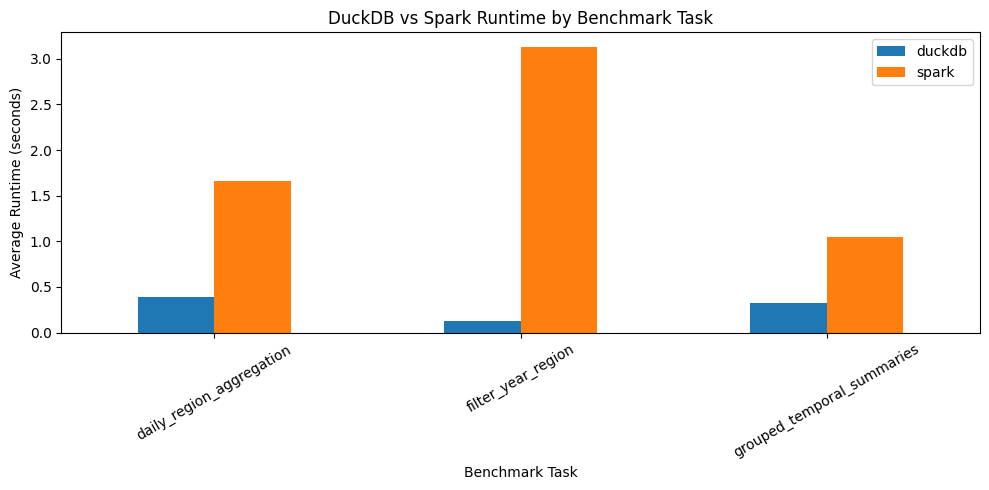

In [6]:
plot_df = comparison.set_index("task_name")[["duckdb", "spark"]]

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("DuckDB vs Spark Runtime by Benchmark Task")
ax.set_xlabel("Benchmark Task")
ax.set_ylabel("Average Runtime (seconds)")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

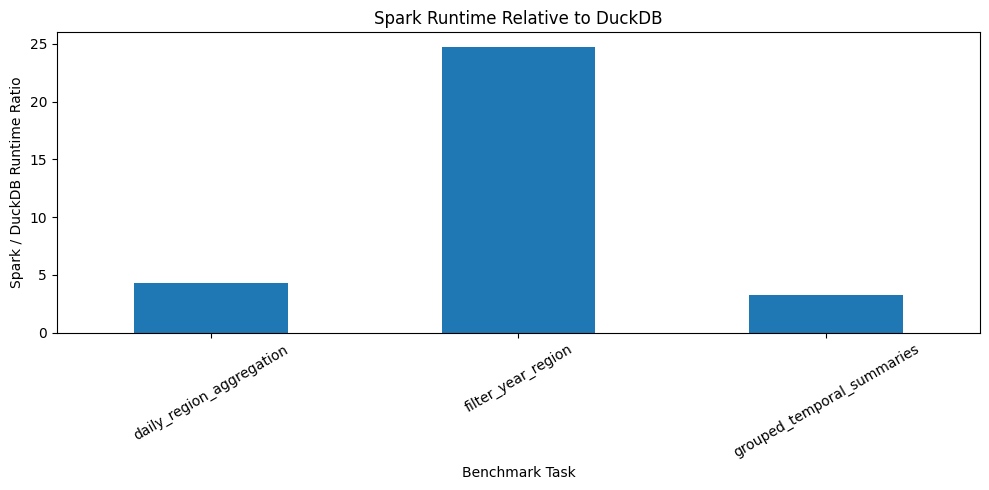

In [7]:
ratio_df = comparison.set_index("task_name")["spark_to_duckdb_runtime_ratio"]

ax = ratio_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("Spark Runtime Relative to DuckDB")
ax.set_xlabel("Benchmark Task")
ax.set_ylabel("Spark / DuckDB Runtime Ratio")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Interpretation

For the small local benchmark subset, DuckDB is faster across all benchmark tasks.

This result is expected because DuckDB is optimized for fast single-node analytical queries over local Parquet files. It avoids the startup and scheduling overhead associated with Spark.

Spark shows higher runtime on the small subset, especially on the first run. This reflects Spark session startup, job planning, task scheduling, and distributed execution overhead.

However, this does not mean Spark is unnecessary for the full project. The full NOAA ISD workload spans many years, many states, and hundreds of gigabytes of weather data. Spark remains justified for distributed S3 reads, large-scale ETL, partitioned Parquet processing, feature table construction, model training, and Airflow-orchestrated production-style execution.

In [8]:
fastest = comparison[["task_name", "dataset_scale", "faster_engine"]]
fastest

,task_name,dataset_scale,faster_engine
0,daily_region_aggregation,small,duckdb
1,filter_year_region,small,duckdb
2,grouped_temporal_summaries,small,duckdb


## Architecture Takeaway

DuckDB is the better tool for:

- local exported subsets
- interactive analysis
- quick validation
- small-to-medium analytical queries
- fast development iteration

Spark is the better tool for:

- full contiguous U.S. processing
- multi-year NOAA ISD workloads
- distributed S3 execution
- large joins and aggregations
- production-style batch pipelines
- Airflow-orchestrated execution

The benchmark supports a hybrid architecture: DuckDB for local analysis and Spark for distributed production-scale processing.

In [9]:
comparison.to_csv(comparison_path, index=False)
summary.to_csv(RESULT_DIR / "benchmark_summary.csv", index=False)

print(f"Saved comparison to: {comparison_path}")
print(f"Saved summary to: {RESULT_DIR / 'benchmark_summary.csv'}")

Saved comparison to: outputs/benchmark_results/benchmark_comparison.csv
Saved summary to: outputs/benchmark_results/benchmark_summary.csv


## Completion Notes

Benchmarking demonstrates compute tradeoffs for the wind forecasting pipeline.

Completion criteria satisfied:

- Benchmark tasks are fair and comparable
- DuckDB and Spark use equivalent workloads
- Results are saved in reproducible CSV outputs
- Small-scale results are interpretable
- Scalability claims are documented through the comparison narrative

Final benchmark outputs:

- `outputs/benchmark_results/duckdb_benchmarks.csv`
- `outputs/benchmark_results/spark_benchmarks.csv`
- `outputs/benchmark_results/benchmark_comparison.csv`
- `outputs/benchmark_results/benchmark_summary.csv`

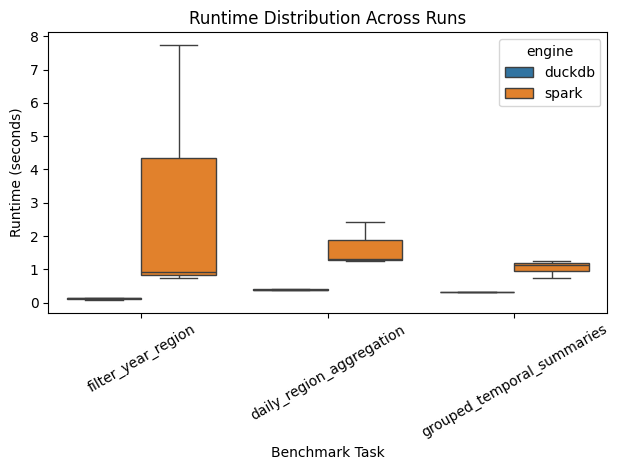

In [14]:
import seaborn as sns

sns.boxplot(
    data=successful_results,
    x="task_name",
    y="runtime_seconds",
    hue="engine"
)

plt.title("Runtime Distribution Across Runs")
plt.xlabel("Benchmark Task")
plt.ylabel("Runtime (seconds)")
plt.xticks(rotation=30)


plt.tight_layout()
plt.show()

The wide distribution for Spark, especially in the filter task, reflects cold-start overhead. Subsequent runs stabilize, but still remain slower than DuckDB for small datasets.